<a href="https://colab.research.google.com/github/nisbenz/DiT-from-Scratch/blob/main/DiT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Diffusion Transformer (DiT) from Scratch — CIFAR-10

A complete, from-scratch implementation of a **Micro-DiT** trained directly in pixel space on CIFAR-10 (32×32×3).

| Component | Spec |
|---|---|
| Patch size | 4×4 → 64 tokens |
| Hidden dim | 384 |
| Heads | 6 |
| Transformer blocks | 6 (adaLN-Zero) |
| Timesteps | 1000 (linear β schedule) |
| Loss | MSE (noise prediction) |

In [11]:

import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# ---------- Hyperparameters ----------
IMAGE_SIZE    = 32
CHANNELS      = 3
PATCH_SIZE    = 4          # 32/4 = 8 → 64 tokens
NUM_PATCHES   = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 64
HIDDEN_DIM    = 384
NUM_HEADS     = 6
NUM_LAYERS    = 6
MLP_RATIO     = 4.0

T             = 1000       # total diffusion timesteps
BETA_START    = 1e-4
BETA_END      = 0.02

BATCH_SIZE    = 128
LEARNING_RATE = 1e-4
EPOCHS        = 80
CKPT_EVERY    = 10         # save checkpoint every N epochs

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


---
## Phase 1 — Data Preparation & Forward Diffusion Process

In [12]:

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                            # [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),           # [-1, 1]
])

train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, drop_last=True,
)

print(f"Dataset size : {len(train_dataset):,}")
print(f"Batches/epoch: {len(train_loader):,}")
print(f"Sample shape : {train_dataset[0][0].shape}")

Dataset size : 50,000
Batches/epoch: 390
Sample shape : torch.Size([3, 32, 32])


In [13]:

betas = torch.linspace(BETA_START, BETA_END, T, dtype=torch.float32)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)              # ā_t

# Pre-compute useful quantities (all shape [T])
sqrt_alpha_bar       = torch.sqrt(alpha_bar)
sqrt_one_minus_ab    = torch.sqrt(1.0 - alpha_bar)
sqrt_recip_alpha     = torch.sqrt(1.0 / alphas)
posterior_variance    = betas * (1.0 - torch.cat([torch.tensor([1.0]), alpha_bar[:-1]])) / (1.0 - alpha_bar)

# Move all to device
betas                = betas.to(device)
alphas               = alphas.to(device)
alpha_bar            = alpha_bar.to(device)
sqrt_alpha_bar       = sqrt_alpha_bar.to(device)
sqrt_one_minus_ab    = sqrt_one_minus_ab.to(device)
sqrt_recip_alpha     = sqrt_recip_alpha.to(device)
posterior_variance    = posterior_variance.to(device)

print(f"β range  : [{betas[0]:.5f}, {betas[-1]:.5f}]")
print(f"ā range  : [{alpha_bar[0]:.5f}, {alpha_bar[-1]:.5f}]")
print(f"Schedule : {T} timesteps")

β range  : [0.00010, 0.02000]
ā range  : [0.99990, 0.00004]
Schedule : 1000 timesteps


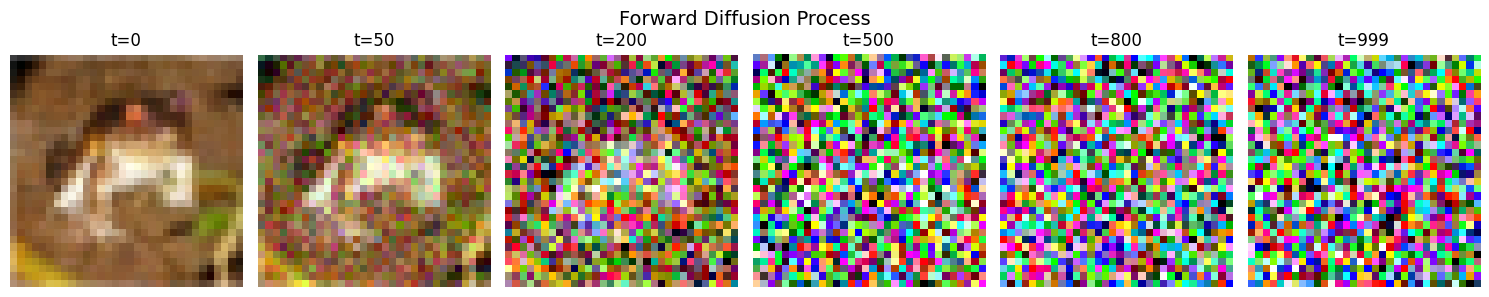

In [14]:

def q_sample(x0, t, noise=None):
    """
    Add noise to x0 at timestep t.
    x_t = sqrt(ā_t) * x_0  +  sqrt(1 - ā_t) * ε
    """
    if noise is None:
        noise = torch.randn_like(x0)
    sa  = sqrt_alpha_bar[t].view(-1, 1, 1, 1)    # [B,1,1,1]
    soa = sqrt_one_minus_ab[t].view(-1, 1, 1, 1)
    return sa * x0 + soa * noise, noise


# --- Quick visualisation ---
sample_img = train_dataset[0][0].unsqueeze(0).to(device)   # [1,3,32,32]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
timesteps_to_show = [0, 50, 200, 500, 800, 999]
for ax, ts in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([ts], device=device)
    noisy, _ = q_sample(sample_img, t_tensor)
    img = noisy[0].cpu().permute(1, 2, 0).clamp(-1, 1) * 0.5 + 0.5
    ax.imshow(img.numpy())
    ax.set_title(f"t={ts}")
    ax.axis("off")
plt.suptitle("Forward Diffusion Process", fontsize=14)
plt.tight_layout()
plt.show()

---
## Phase 2 — Building the Micro-DiT Architecture

In [15]:

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """
    Generate 2D sine-cosine positional embeddings.
    Returns: [grid_size*grid_size, embed_dim]
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid   = np.meshgrid(grid_w, grid_h)          # [2, G, G]
    grid   = np.stack(grid, axis=0).reshape(2, -1) # [2, G*G]

    half_dim = embed_dim // 2
    emb = np.log(10000.0) / (half_dim // 2 - 1)
    emb = np.exp(np.arange(half_dim // 2) * -emb)  # [D/4]

    # Outer product for each spatial dim
    emb_h = grid[0][:, None] * emb[None, :]   # [N, D/4]
    emb_w = grid[1][:, None] * emb[None, :]   # [N, D/4]

    emb_h = np.concatenate([np.sin(emb_h), np.cos(emb_h)], axis=1)  # [N, D/2]
    emb_w = np.concatenate([np.sin(emb_w), np.cos(emb_w)], axis=1)  # [N, D/2]

    pos_embed = np.concatenate([emb_h, emb_w], axis=1)  # [N, D]
    return torch.from_numpy(pos_embed).float()

# Quick sanity check
_pe = get_2d_sincos_pos_embed(HIDDEN_DIM, IMAGE_SIZE // PATCH_SIZE)
print(f"Positional embedding shape: {_pe.shape}")   # [64, 384]

Positional embedding shape: torch.Size([64, 384])


In [16]:

class TimestepEmbedder(nn.Module):
    """
    Embeds scalar timestep into a dense vector.
    sinusoidal → Linear → SiLU → Linear
    """
    def __init__(self, hidden_dim, freq_dim=256):
        super().__init__()
        self.freq_dim = freq_dim
        self.mlp = nn.Sequential(
            nn.Linear(freq_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def sinusoidal_embedding(self, t):
        half = self.freq_dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=t.device) / half
        )
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

    def forward(self, t):
        emb = self.sinusoidal_embedding(t)   # [B, freq_dim]
        return self.mlp(emb)                  # [B, hidden_dim]

# Quick test
_te = TimestepEmbedder(HIDDEN_DIM).to(device)
_out = _te(torch.tensor([0, 500, 999], device=device))
print(f"Timestep embedding shape: {_out.shape}")  # [3, 384]

Timestep embedding shape: torch.Size([3, 384])


In [17]:

def modulate(x, shift, scale):
    """Apply adaptive layer norm modulation: scale * x + shift."""
    return x * (1.0 + scale.unsqueeze(1)) + shift.unsqueeze(1)


class DiTBlock(nn.Module):
    """
    A DiT block with adaptive layer norm zero (adaLN-Zero).
    The timestep conditioning produces 6 modulation parameters:
      γ₁, β₁ (pre-attention norm), α₁ (attention gate),
      γ₂, β₂ (pre-FFN norm),     α₂ (FFN gate).
    All gates are initialised to zero → identity at init.
    """
    def __init__(self, hidden_dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        self.attn  = nn.MultiheadAttention(
            hidden_dim, num_heads, batch_first=True
        )
        self.norm2 = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        mlp_hidden = int(hidden_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden),
            nn.GELU(),
            nn.Linear(mlp_hidden, hidden_dim),
        )
        # adaLN modulation: projects timestep emb → 6 vectors
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_dim, 6 * hidden_dim),
        )
        # Zero-init the modulation output so block starts as identity
        nn.init.zeros_(self.adaLN_modulation[1].weight)
        nn.init.zeros_(self.adaLN_modulation[1].bias)

    def forward(self, x, c):
        """
        x : [B, N, D]  — token sequence
        c : [B, D]     — timestep conditioning vector
        """
        # Compute 6 modulation params from conditioning
        shift1, scale1, gate1, shift2, scale2, gate2 = \
            self.adaLN_modulation(c).chunk(6, dim=-1)    # each [B, D]

        # --- Self-Attention ---
        h = modulate(self.norm1(x), shift1, scale1)
        h, _ = self.attn(h, h, h)
        x = x + gate1.unsqueeze(1) * h

        # --- Feed-Forward ---
        h = modulate(self.norm2(x), shift2, scale2)
        h = self.mlp(h)
        x = x + gate2.unsqueeze(1) * h

        return x

# Quick test
_blk = DiTBlock(HIDDEN_DIM, NUM_HEADS).to(device)
_x = torch.randn(2, 64, HIDDEN_DIM, device=device)
_c = torch.randn(2, HIDDEN_DIM, device=device)
print(f"Block output shape: {_blk(_x, _c).shape}")  # [2, 64, 384]

Block output shape: torch.Size([2, 64, 384])


In [18]:

class FinalLayer(nn.Module):
    """
    The final layer of DiT: adaLN-modulated norm → linear projection
    to patch_size² * channels.
    """
    def __init__(self, hidden_dim, patch_size, out_channels):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        self.linear = nn.Linear(
            hidden_dim, patch_size * patch_size * out_channels
        )
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_dim, 2 * hidden_dim),
        )
        # Zero-init
        nn.init.zeros_(self.adaLN_modulation[1].weight)
        nn.init.zeros_(self.adaLN_modulation[1].bias)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=-1)
        x = modulate(self.norm(x), shift, scale)
        x = self.linear(x)
        return x

In [19]:

class MicroDiT(nn.Module):
    """
    Diffusion Transformer for 32×32×3 images.
    Patchify → Pos-Embed → N×(adaLN-Zero blocks) → FinalLayer → Unpatchify
    """
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        hidden_dim=384,
        num_heads=6,
        num_layers=6,
        mlp_ratio=4.0,
    ):
        super().__init__()
        self.patch_size   = patch_size
        self.in_channels  = in_channels
        self.grid_size    = image_size // patch_size  # 8
        self.num_patches  = self.grid_size ** 2       # 64

        # --- Patchification (Conv2d) ---
        self.patch_embed = nn.Conv2d(
            in_channels, hidden_dim,
            kernel_size=patch_size, stride=patch_size,
        )

        # --- Positional Embedding (fixed, not learned) ---
        pos_embed = get_2d_sincos_pos_embed(hidden_dim, self.grid_size)
        self.register_buffer(
            "pos_embed", pos_embed.unsqueeze(0)  # [1, 64, D]
        )

        # --- Timestep Embedding ---
        self.time_embed = TimestepEmbedder(hidden_dim)

        # --- Transformer Blocks ---
        self.blocks = nn.ModuleList([
            DiTBlock(hidden_dim, num_heads, mlp_ratio)
            for _ in range(num_layers)
        ])

        # --- Final Layer (Decoder / Unpatchify) ---
        self.final_layer = FinalLayer(hidden_dim, patch_size, in_channels)

        self.initialize_weights()

    def initialize_weights(self):
        # Standard init for linear & conv layers
        def _init(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        self.apply(_init)
        # Re-zero the adaLN modulation outputs (they were just overwritten)
        for block in self.blocks:
            nn.init.zeros_(block.adaLN_modulation[1].weight)
            nn.init.zeros_(block.adaLN_modulation[1].bias)
        nn.init.zeros_(self.final_layer.adaLN_modulation[1].weight)
        nn.init.zeros_(self.final_layer.adaLN_modulation[1].bias)
        nn.init.zeros_(self.final_layer.linear.weight)
        nn.init.zeros_(self.final_layer.linear.bias)

    def unpatchify(self, x):
        """
        x: [B, N, patch_size² * C]
        Returns: [B, C, H, W]
        """
        B, N, _ = x.shape
        p = self.patch_size
        c = self.in_channels
        g = self.grid_size
        # [B, g, g, p, p, C]
        x = x.reshape(B, g, g, p, p, c)
        # [B, C, g, p, g, p] → [B, C, H, W]
        x = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        x = x.reshape(B, c, g * p, g * p)
        return x

    def forward(self, x, t):
        """
        x : [B, C, H, W]  — noisy image
        t : [B]            — timesteps
        Returns: [B, C, H, W]  — predicted noise
        """
        # 1) Patchify
        x = self.patch_embed(x)                        # [B, D, g, g]
        x = x.flatten(2).transpose(1, 2)               # [B, N, D]

        # 2) Add positional embedding
        x = x + self.pos_embed

        # 3) Timestep conditioning
        c = self.time_embed(t)                         # [B, D]

        # 4) Transformer blocks
        for block in self.blocks:
            x = block(x, c)

        # 5) Final layer + unpatchify
        x = self.final_layer(x, c)                     # [B, N, p*p*C]
        x = self.unpatchify(x)                         # [B, C, H, W]
        return x


# ---------- Instantiate & print stats ----------
model = MicroDiT(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    hidden_dim=HIDDEN_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_ratio=MLP_RATIO,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Shape sanity check
with torch.no_grad():
    dummy_x = torch.randn(2, 3, 32, 32, device=device)
    dummy_t = torch.randint(0, T, (2,), device=device)
    out = model(dummy_x, dummy_t)
    print(f"Input shape : {dummy_x.shape}")
    print(f"Output shape: {out.shape}")
    assert out.shape == dummy_x.shape, "Shape mismatch!"
    print(" Shape check passed!")

Total parameters: 16,539,312
Input shape : torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 3, 32, 32])
 Shape check passed!


---
## Phase 3 — Training Loop

In [20]:

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

os.makedirs("checkpoints", exist_ok=True)

loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch_idx, (images, _) in enumerate(pbar):
        images = images.to(device)                     # [B, 3, 32, 32]

        # Sample random timesteps for each image in the batch
        t = torch.randint(0, T, (images.shape[0],), device=device)

        # Forward diffusion: add noise
        noise = torch.randn_like(images)
        x_t, _ = q_sample(images, t, noise)

        # Predict noise with DiT
        noise_pred = model(x_t, t)

        # MSE loss between actual and predicted noise
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"  → Epoch {epoch} avg loss: {avg_loss:.5f}")

    # Checkpoint
    if epoch % CKPT_EVERY == 0:
        ckpt_path = f"checkpoints/dit_epoch_{epoch}.pt"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss,
        }, ckpt_path)
        print(f"   Saved checkpoint: {ckpt_path}")

print("\n Training complete!")

Epoch 1/80:   0%|          | 0/390 [00:00<?, ?it/s]

  → Epoch 1 avg loss: 0.15106


Epoch 2/80:   0%|          | 0/390 [00:00<?, ?it/s]

  → Epoch 2 avg loss: 0.05279


Epoch 3/80:   0%|          | 0/390 [00:00<?, ?it/s]

...

  → Epoch 78 avg loss: 0.03363


Epoch 79/80:   0%|          | 0/390 [00:00<?, ?it/s]

  → Epoch 79 avg loss: 0.03295


Epoch 80/80:   0%|          | 0/390 [00:00<?, ?it/s]

  → Epoch 80 avg loss: 0.03307
   Saved checkpoint: checkpoints/dit_epoch_80.pt

 Training complete!


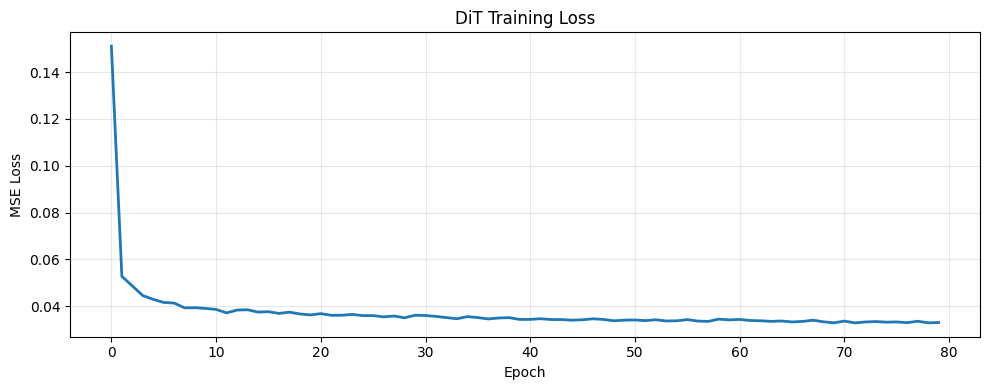

In [21]:

plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DiT Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Phase 4 — Sampling (Reverse Diffusion Process)

In [31]:

@torch.no_grad()
def ddpm_sample(model, n_samples=16, image_size=32, channels=3):
    """
    Generate images by iteratively denoising from pure Gaussian noise.
    Standard DDPM reverse process:  p(x_{t-1} | x_t)
    """
    model.eval()
    shape = (n_samples, channels, image_size, image_size)

    # Start from pure noise
    x = torch.randn(shape, device=device)

    for t_idx in tqdm(reversed(range(T)), total=T, desc="Sampling"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.long)

        # Predict noise
        eps_pred = model(x, t_batch)

        # DDPM reverse step
        beta_t          = betas[t_idx]
        alpha_t         = alphas[t_idx]
        alpha_bar_t     = alpha_bar[t_idx]
        sqrt_recip_a_t  = sqrt_recip_alpha[t_idx]

        # Predict mean:  μ = (1/sqrt(α_t)) * (x_t - (β_t / sqrt(1-ā_t)) * ε_θ)
        mean = sqrt_recip_a_t * (
            x - (beta_t / sqrt_one_minus_ab[t_idx]) * eps_pred
        )

        if t_idx > 0:
            # Add stochastic noise (except at t=0)
            noise = torch.randn_like(x)
            sigma = torch.sqrt(posterior_variance[t_idx])
            x = mean + sigma * noise
        else:
            x = mean

    model.train()
    return x

print("Sampling function ready.")

Sampling function ready.


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

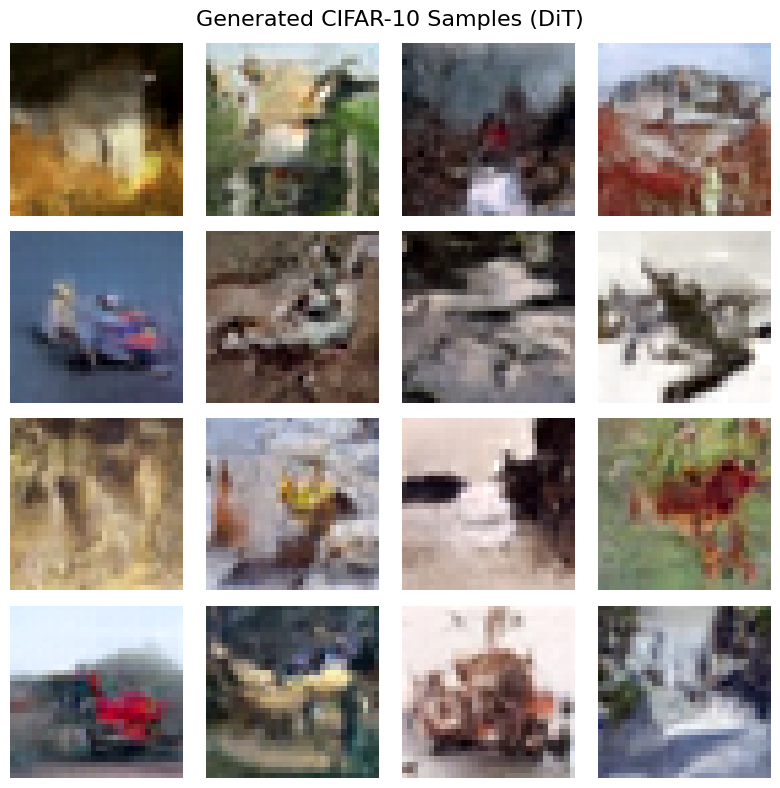


Sample pixel range: [0.000, 1.000]


In [32]:

n_samples = 16
samples = ddpm_sample(model, n_samples=n_samples)

# Un-normalise from [-1,1] → [0,1] for display
samples = (samples.clamp(-1, 1) + 1) / 2.0

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = samples[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Generated CIFAR-10 Samples (DiT)", fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nSample pixel range: [{samples.min():.3f}, {samples.max():.3f}]")

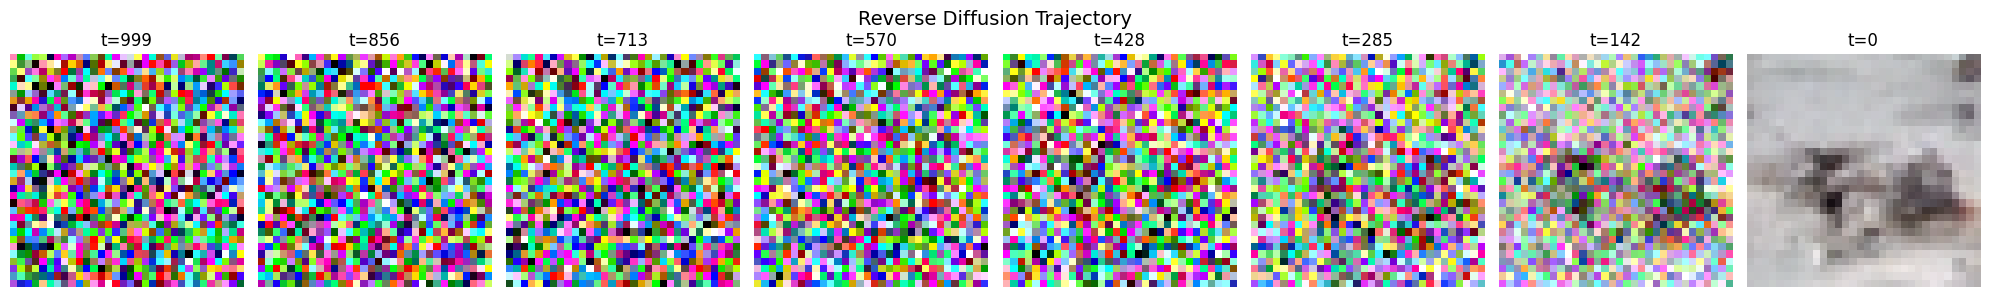

In [36]:

@torch.no_grad()
def ddpm_sample_with_trajectory(model, n_snapshots=8):
    """Sample one image and capture snapshots along the way."""
    model.eval()
    x = torch.randn(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
    snapshots = []
    snapshot_steps = np.linspace(T - 1, 0, n_snapshots, dtype=int)

    for t_idx in reversed(range(T)):
        t_batch = torch.full((1,), t_idx, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)

        mean = sqrt_recip_alpha[t_idx] * (
            x - (betas[t_idx] / sqrt_one_minus_ab[t_idx]) * eps_pred
        )
        if t_idx > 0:
            x = mean + torch.sqrt(posterior_variance[t_idx]) * torch.randn_like(x)
        else:
            x = mean

        if t_idx in snapshot_steps:
            img = (x[0].cpu().clamp(-1, 1) + 1) / 2.0
            snapshots.append((t_idx, img.permute(1, 2, 0).numpy()))

    model.train()
    return snapshots

snaps = ddpm_sample_with_trajectory(model)
fig, axes = plt.subplots(1, len(snaps), figsize=(2.5 * len(snaps), 3))
for ax, (t_val, img) in zip(axes, snaps):
    ax.imshow(img)
    ax.set_title(f"t={t_val}")
    ax.axis("off")
plt.suptitle("Reverse Diffusion Trajectory", fontsize=14)
plt.tight_layout()
plt.show()